In [48]:
#install.packages(c("readr", "dplyr", "purrr", "ggplot2", "tidyr"))

library(readr)
library(dplyr)
library(purrr)
library(ggplot2)
library(tidyr)

In [47]:
Load the csv files

ERROR: Error in parse(text = input): <text>:1:6: unexpected symbol
1: Load the
         ^


In [22]:
output_directory <- "output"

In [25]:
csv_files <- list.files(
    path = output_directory,
    pattern = "benchmark_results.*\\csv",
    recursive = TRUE,
    full.names = TRUE
)

In [26]:
print(csv_files)

[1] "output/2025-09-24_23-39-28/benchmark_results_2025-09-25_02-39-29.csv"
[2] "output/2025-09-24_23-40-51/benchmark_results_2025-09-25_02-40-52.csv"
[3] "output/2025-09-24_23-42-47/benchmark_results_2025-09-25_02-42-54.csv"
[4] "output/2025-09-25_21-17-42/benchmark_results_2025-09-26_00-17-43.csv"
[5] "output/2025-10-01_20-08-19/benchmark_results_2025-10-01_23-08-20.csv"
[6] "output/2025-10-01_21-34-16/benchmark_results_2025-10-02_00-34-18.csv"
[7] "output/2025-10-01_23-34-39/benchmark_results_2025-10-02_02-34-41.csv"
[8] "output/2025-10-02_08-15-15/benchmark_results_2025-10-02_11-15-17.csv"


In [27]:
df <- map_dfr(
    csv_files,
    ~ read_csv(.x, show_col_types = FALSE) %>% 
    mutate(filename = basename(.x)) %>%
    filter(original_size_b != 0)
)

In [35]:
df %>%
    filter(size_mb == 10) %>%
    arrange(algorithm, run)

algorithm,size_mb,run,compression_time_ms,decompression_time_ms,original_size_b,compressed_size_b,compression_ratio_pct,comp_cycles,comp_instructions,comp_branch_misses,decomp_cycles,decomp_instructions,decomp_branch_misses,filename
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
bzip2,10,1,1328.96,666.03,10485790,2268840,21.64,3046340127,3565391075,54367439,1524919722,1209254651,12295199,benchmark_results_2025-09-26_00-17-43.csv
bzip2,10,1,1336.55,674.65,10485788,2269322,21.64,3064437323,3577921192,54561813,1545628119,1209189286,12323414,benchmark_results_2025-10-01_23-08-20.csv
bzip2,10,1,1338.95,677.51,10485802,2268044,21.63,3069170701,3567185049,54363270,1552143024,1209187356,12317092,benchmark_results_2025-10-02_00-34-18.csv
bzip2,10,1,1336.04,663.81,10485785,2268213,21.63,3062998738,3571715625,54514703,1521028613,1208931979,12250642,benchmark_results_2025-10-02_02-34-41.csv
bzip2,10,1,1336.62,665.07,10485786,2267560,21.63,3064098322,3565509857,54369694,1523602435,1208406700,12326881,benchmark_results_2025-10-02_11-15-17.csv
bzip2,10,2,1327.36,698.23,10485790,2268840,21.64,3043503668,3566088109,54341089,1546011504,1209689295,12367765,benchmark_results_2025-09-26_00-17-43.csv
bzip2,10,2,1339.85,677.09,10485788,2269322,21.64,3071646817,3577183488,54570767,1551104727,1209216764,12319199,benchmark_results_2025-10-01_23-08-20.csv
bzip2,10,2,1349.71,680.19,10485802,2268044,21.63,3056670482,3567275737,54409324,1557895744,1208714623,12301943,benchmark_results_2025-10-02_00-34-18.csv
bzip2,10,2,1334.17,676.40,10485785,2268213,21.63,3058939446,3571717298,54507912,1550190517,1208678638,12321701,benchmark_results_2025-10-02_02-34-41.csv


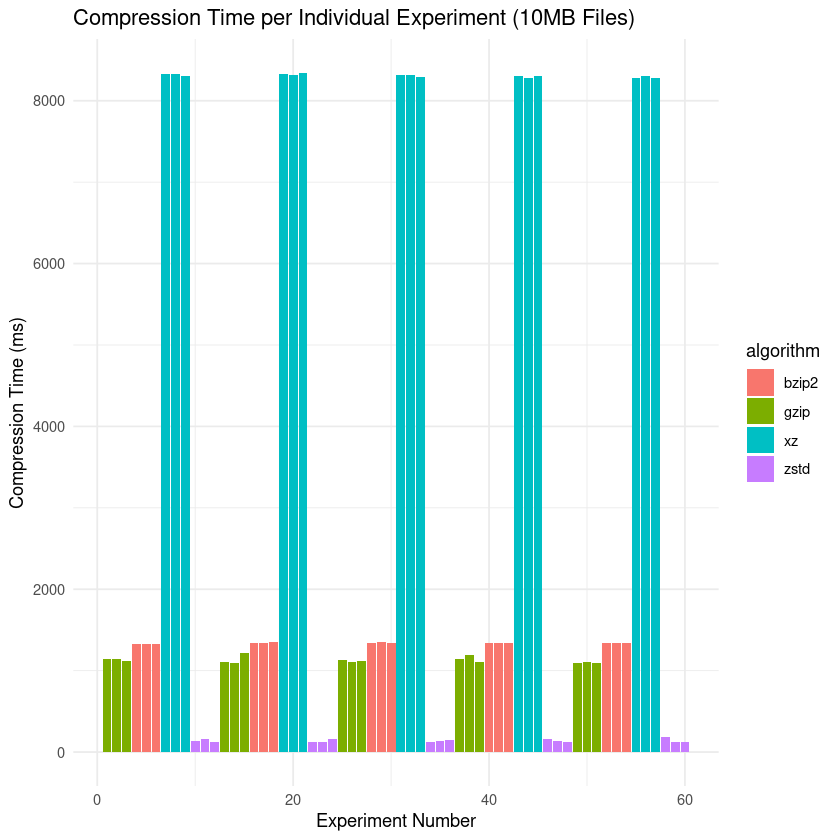

In [39]:
df %>%
    filter(size_mb == 10) %>%
    # arrange(algorithm, run) %>%
    mutate(observation = row_number()) %>%
    ggplot(aes(x = observation, y = compression_time_ms, fill = algorithm)) +
    geom_col() +
    labs(
    title = "Compression Time per Individual Experiment (10MB Files)",
    x = "Experiment Number",
    y = "Compression Time (ms)"
    ) +
    theme_minimal()

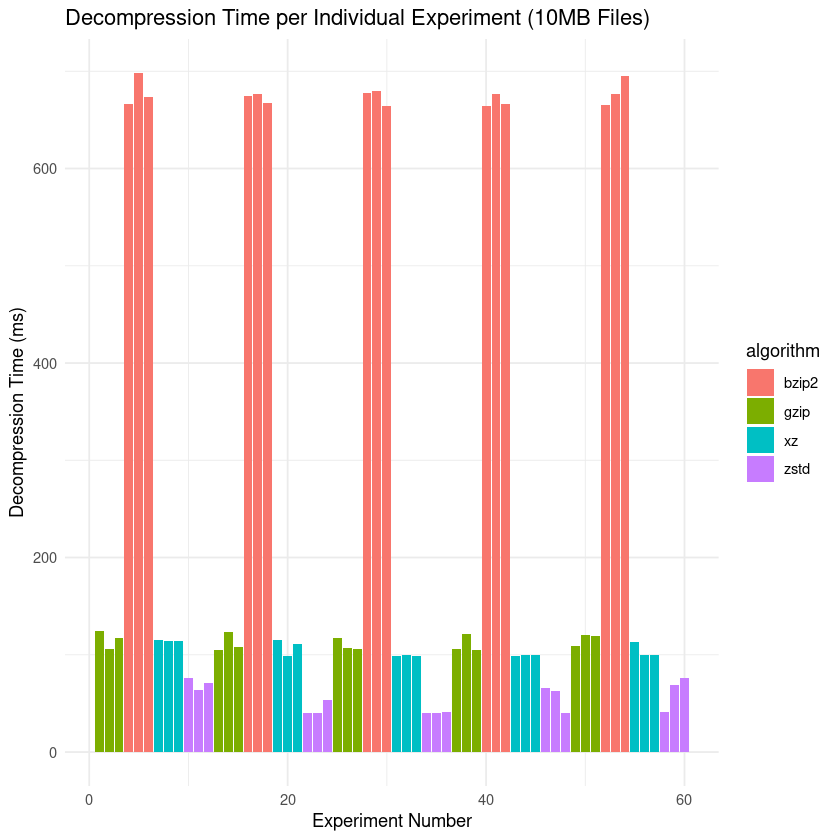

In [58]:
df %>%
    filter(size_mb == 10) %>%
    # arrange(algorithm, run) %>%
    mutate(observation = row_number()) %>%
    ggplot(aes(x = observation, y = decompression_time_ms, fill = algorithm)) +
    geom_col() +
    labs(
    title = "Decompression Time per Individual Experiment (10MB Files)",
    x = "Experiment Number",
    y = "Decompression Time (ms)"
    ) +
    theme_minimal()

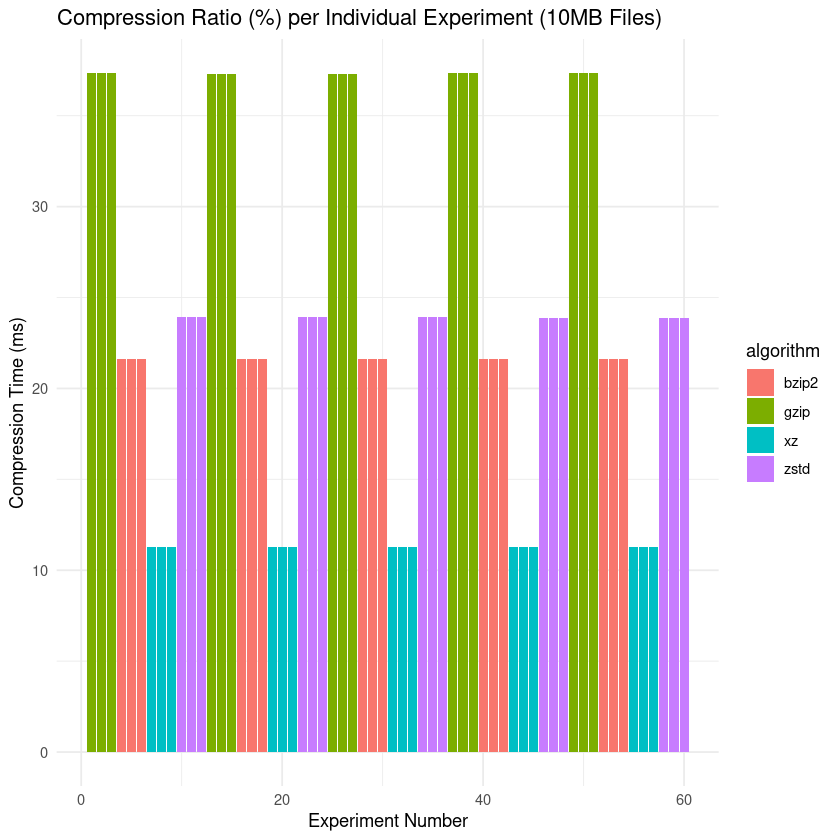

In [57]:
df %>%
    filter(size_mb == 10) %>%
    # arrange(algorithm, run) %>%
    mutate(observation = row_number()) %>%
    ggplot(aes(x = observation, y = compression_ratio_pct, fill = algorithm)) +
    geom_col() +
    labs(
    title = "Compression Ratio (%) per Individual Experiment (10MB Files)",
    x = "Experiment Number",
    y = "Compression Time (ms)"
    ) +
    theme_minimal()

In [111]:
plot<-df %>%
    filter(size_mb == 10) %>%
    mutate(observation = row_number()) %>%
    pivot_longer(
        cols = c(compression_time_ms, decompression_time_ms, compression_ratio_pct),
        names_to = "metric",
        values_to = "value"
    ) %>%
    mutate(metric = factor(metric, levels = c(
        "compression_time_ms", 
        "decompression_time_ms", 
        "compression_ratio_pct"
    ))) %>%
    ggplot(aes(x = observation, y = value, fill = algorithm)) +
    geom_col(show.legend = TRUE) +
    facet_wrap(~ metric,  strip.position = "bottom", scales = "free_y", nrow=3) +
    labs(
        title = "Algorithm Performance for 10MB Files",
        x = NULL,
        y = NULL
    ) +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))


In [112]:
ggsave("perfomance_plot.png",
    plot = plot,  
    width = 1600,
    height = 720*3,
    units = "px"
)

In [124]:
sizes_to_plot <- c(10, 100, 1000)

for (current_size in sizes_to_plot) {
  
  plot<-df %>%
    filter(size_mb == current_size) %>%
    mutate(observation = row_number()) %>%
    pivot_longer(
        cols = c(compression_time_ms, decompression_time_ms, compression_ratio_pct),
        names_to = "metric",
        values_to = "value"
    ) %>%
    mutate(metric = factor(metric, levels = c(
        "compression_time_ms", 
        "decompression_time_ms", 
        "compression_ratio_pct"
    ))) %>%
    ggplot(aes(x = observation, y = value, fill = algorithm)) +
    geom_col(show.legend = TRUE) +
    facet_wrap(~ metric,  strip.position = "bottom", scales = "free_y", nrow=3) +
    labs(
        title = paste("Algorithm Performance", current_size, "MB for Files"),
        x = NULL,
        y = NULL
    ) +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))
  
  # Create a dynamic filename for each plot
  filename <- paste("performance_plot_", current_size, "_mb.png", sep="")
  
  # Save the current plot to the dynamic filename
  ggsave(
    filename,
    plot = plot,
    width = 1600,
    height = 720*3, 
    units = "px"
  )
}